# SSNE - Mini Projekt 3

**autorzy**:
- Katarzyna Kanicka,
- Hanna Zarzycka

### Treść zadania
Zadanie polega na stworzeniu klasyfikatora obrazków przypisującego zadanym wejściom jedną z 50 klas, takich jak przedmioty czy zwierzęta. Do dyspozycji mają Państwo:
- `train.zip` - archiwum ze zbiorem treningowym, w którym obrazom przyporządkowane zostały ich klasy na podstawie podfolderów, w których się one znajdują. Zbiór treningowy przygotowany jest tak, żeby można było go łatwo załadować za pomocą klasy `ImageFolder`, przykładowo jako:
```
import torchvision

trainset = torchvision.datasets.ImageFolder("train/")

map_class_to_idx = dataset_clean.class_to_idx  # map nazwy klasy na index
```
- `test.zip` - zbiór testowy z obrazami, bez przypisanych klas.

Skuteczność stworzonego przez Państwa modelu będę sprawdzał w oparciu o **średnie accuracy na wszystkich klasach**, którego kod zamieściłem w pliku `helpers.py`.

**Uwaga!**
Proszę dokładnie zastosować się do poniższej instrukcji i sprawdzić czy przesłane przez Państwa rozwiązanie jest zgodne z każdym podpunktem:
- W ramach rozwiązania zabronione jest używanie gotowych modeli i ich architektur. Celem tego projektu jest opracowanie własnej architektury i wytrenowanie jej od początku, wyłącznie w oparciu o dostarczone dane (lub ich augmentacje). **Skorzystanie w JAKIKOLWIEK sposób z gotowych modeli będzie wiązać się z wyzerowaniem Państwa punktów w ramach tego projektu!**
- Jako rozwiązanie proszę oddać poprzez MS Teams Assignment jeden plik .zip zawierający: kod (w formie notebooka lub skryptu .py) oraz plik `pred.csv` z predykcjami wykonanymi na zbiorze testowym.
- Proszę nazwać plik .zip nazwiskami i imionami obu autorów z grupy ALFABETYCZNIE. Nazwę archiwum zip proszę dodatkowo rozpocząć od przedrostka poniedzialek_ lub sroda_ lub piatek_ (NIE pon/pia/śr /inne wersje).  Przykład: sroda_MałyszAdam_ŚwiątekIga.zip
- Proszę plik z predykcjami nazwać `pred.csv`. W pliku tym powinny znajdować się dokładnie dwie kolumny: nazwy plików wskazujących zdjęcia ze zbioru testowego (str) oraz przypisane im klasy w zakresie 0-49 (int). Koniecznie proszę sprawdzić format zwracanych przez Państwa predykcji (tyle predykcji, ile elementów w zbiorze testowym, brak nagłówków, dwie kolumny itd.). W plikach zamieściłem przykładowy plik "pred.csv" w oczekiwanym formacie. W szczególności, proszę zwrócić uwagę, żeby pliki nazywały się dokładnie tak samo jak w zbiorze testowym, czyli np. IMG_000134.JPEG (a nie: 000134.JPEG, IMG_000134.jpeg, IMG_000134).
- Proszę nie umieszczać plików w dodatkowych podfolderach, tylko bezpośrednio w archiwum. Struktura przykładowego pliku zip:
```
poniedzialek_KanickaKatarzyna_ZarzyckaHanna.zip
├── pred.csv
└── rozwiazanie.ipynb
```
  - Prosiłbym o nieprzesyłanie do mnie plików zbioru treningowego czy testowego.
  - W MS Teams zadanie jest przydzielone każdemu, ale proszę, żeby tylko jeden (dowolny) członek zespołu je zwrócił.
  
**Niezastosowanie się do instrukcji może skutkować obniżeniem punktacji, ponieważ ewaluacja wyników jest automatyczna, a niespójne nazwy i pliki mogą spowodować złe wczytanie plików do testowania.**

W razie pytań zapraszam na konsultacje.

In [ ]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.0 MB/s eta 0:00:00


In [ ]:
import torch
import random
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
SEED = 28

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

## Przygotowanie danych

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.zip to train.zip
Saving test.zip to test.zip


In [ ]:
!unzip train.zip -d /content/

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: /content/train/bird/n01503976_4927.JPEG  
  inflating: /content/train/bird/n01514668_14756.JPEG  
  inflating: /content/train/bird/n01503976_19669.JPEG  
  inflating: /content/train/bird/n01503976_8159.JPEG  
  inflating: /content/train/bird/n01514668_546.JPEG  
  inflating: /content/train/bird/n01503976_7492.JPEG  
  inflating: /content/train/bird/n01503976_20280.JPEG  
  inflating: /content/train/bird/n01514668_4262.JPEG  
  inflating: /content/train/bird/n01503976_12861.JPEG  
  inflating: /content/train/bird/n01514668_16317.JPEG  
  inflating: /content/train/bird/n01514668_17760.JPEG  
  inflating: /content/train/bird/n01503976_8911.JPEG  
  inflating: /content/train/bird/n01503976_17646.JPEG  
  inflating: /content/train/bird/n01514668_13688.JPEG  
  inflating: /content/train/bird/n01503976_17627.JPEG  
  inflating: /content/train/bird/n01514668_4493.JPEG  
  inflating: /content/train/bird/n01503976_1201

In [ ]:
!unzip test.zip -d /content/test

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: /content/test/test/IMG_383832.JPEG  
  inflating: /content/test/test/IMG_190687.JPEG  
  inflating: /content/test/test/IMG_409671.JPEG  
  inflating: /content/test/test/IMG_167134.JPEG  
  inflating: /content/test/test/IMG_158908.JPEG  
  inflating: /content/test/test/IMG_917268.JPEG  
  inflating: /content/test/test/IMG_373007.JPEG  
  inflating: /content/test/test/IMG_055156.JPEG  
  inflating: /content/test/test/IMG_501275.JPEG  
  inflating: /content/test/test/IMG_041595.JPEG  
  inflating: /content/test/test/IMG_820292.JPEG  
  inflating: /content/test/test/IMG_049148.JPEG  
  inflating: /content/test/test/IMG_372307.JPEG  
  inflating: /content/test/test/IMG_005061.JPEG  
  inflating: /content/test/test/IMG_316946.JPEG  
  inflating: /content/test/test/IMG_139651.JPEG  
  inflating: /content/test/test/IMG_604304.JPEG  
  inflating: /content/test/test/IMG_387986.JPEG  
  inflating: /content/test/test/IMG

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.3, contrast=0.25),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(0.12),
])

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder(root="/content/train", transform=train_transform)
val_data = datasets.ImageFolder(root="/content/train", transform=transform)
test_data = datasets.ImageFolder(root="/content/test", transform=transform)

In [ ]:
len(train_data)

88011

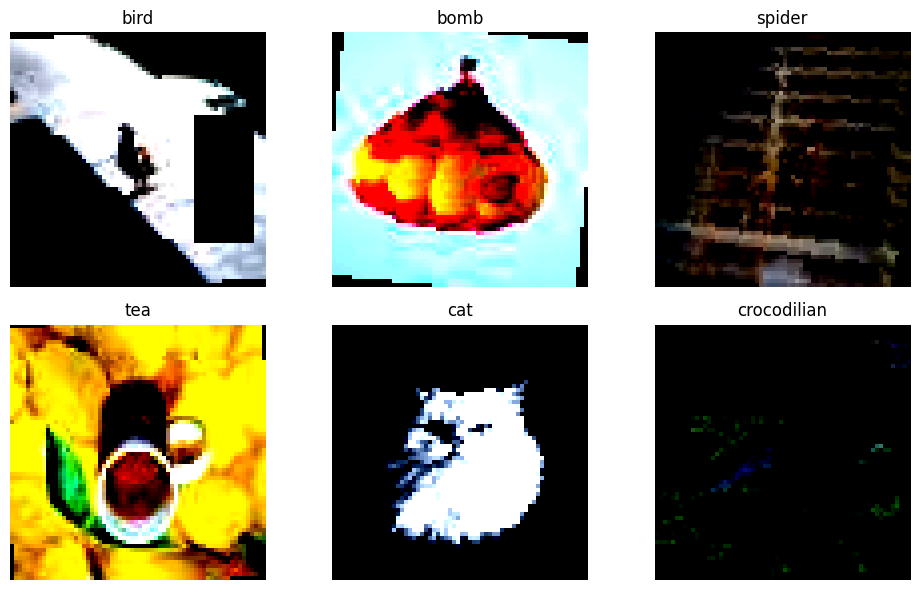

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

indices = random.sample(range(len(train_data)), 6)

for ax, idx in zip(axes.flatten(), indices):
    img, label = train_data[idx]

    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(train_data.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_data.classes
train_data.class_to_idx

{'acoustic': 0,
 'antenna': 1,
 'bacteria': 2,
 'battery': 3,
 'bean': 4,
 'beetle': 5,
 'bicycle': 6,
 'birch': 7,
 'bird': 8,
 'bomb': 9,
 'bread': 10,
 'bridge': 11,
 'camera': 12,
 'carbon': 13,
 'cat': 14,
 'corn': 15,
 'crab': 16,
 'crocodilian': 17,
 'echinoderm': 18,
 'egg': 19,
 'elephant': 20,
 'fish': 21,
 'flower': 22,
 'frog': 23,
 'fungus': 24,
 'gauge': 25,
 'hammer': 26,
 'icecream': 27,
 'kangaroo': 28,
 'memorial': 29,
 'monkey': 30,
 'motor': 31,
 'nest': 32,
 'palm': 33,
 'pizza': 34,
 'pot': 35,
 'printer': 36,
 'saw': 37,
 'snake': 38,
 'spice': 39,
 'spider': 40,
 'spoon': 41,
 'squash': 42,
 'swine': 43,
 'tea': 44,
 'tomato': 45,
 'towel': 46,
 'truck': 47,
 'turtle': 48,
 'worm': 49}

In [ ]:
targets = train_data.targets
indices = list(range(len(train_data)))

In [ ]:
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=targets, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, stratify=[targets[i] for i in train_idx], random_state=SEED)

In [ ]:
train_dataset = data.Subset(train_data, train_idx)
val_dataset   = data.Subset(val_data, val_idx)
test_dataset  = data.Subset(val_data, test_idx)

ds = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

In [ ]:
len(train_dataset), len(val_dataset), len(test_dataset)

(52806, 17602, 17603)

In [ ]:
BATCH_SIZE = 128

dataloaders = {split: data.DataLoader(ds[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=2, pin_memory=True) for split in ds}

##Model

In [ ]:
import torch.nn as nn
import torch

class ImageClassifier(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=5, padding=2)
        self.bn2d4 = nn.BatchNorm2d(256)
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.fc1 = nn.Linear(4096, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))
        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))
        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))
        x = self.pool1(self.relu(self.bn2d4(self.conv4(x))))

        x = torch.flatten(x, start_dim=1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
# Check dims before flatten
model = ImageClassifier(n_classes=50, hidden_1=256, hidden_2=128)
with torch.no_grad():
    x = torch.zeros(1, 3, 64, 64)
    x = model.conv1(x)
    x = model.bn2d1(x)
    x = model.pool1(x)
    x = model.conv2(x)
    x = model.pool1(x)
    x = model.conv3(x)
    x = model.pool1(x)
    x = model.conv4(x)
    x = model.pool1(x)
    print(x.shape)

torch.Size([1, 256, 4, 4])


##Trening

In [ ]:
import torchmetrics
import torch.nn as nn
from torch.utils.data import DataLoader

def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler, num_epochs: int):

    # Early stopping parameters
    best_val_loss = float('inf')
    patience = 5
    epochs_no_improve = 0
    best_model_weights = None

    # Metrics
    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    metrics = dict()
    # Run all epochs
    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            # Loop over each batch in the data loader
            for X_batch, target in tqdm(loaders[phase]):
                X_batch = X_batch.to(device)
                target = target.to(device).long()

                # Reset gradient
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X_batch)
                    _, preds = torch.max(logits, dim=1)
                    loss = criterion(logits, target)

                    metric_loss(loss)
                    metric_acc(logits, target)

                    # Backward
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            # Statistics for batch
            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()

            current_lr = lr_scheduler.get_last_lr()[0]
            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
            if epoch not in metrics:
              metrics[epoch] = {}
            metrics[epoch][f"loss {phase}"] = mean_loss.item()
            metrics[epoch][f"accuracy {phase}"] = acc.item()

            # Early stopping
            if phase == 'val':
                val_loss = mean_loss.item()

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    best_model_weights = model.state_dict()
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    model.load_state_dict(best_model_weights)
                    return metrics

            metric_loss.reset()
            metric_acc.reset()

        lr_scheduler.step()
    return metrics

In [ ]:
def plot_training_curves(metrics):
    epochs = sorted(metrics.keys())

    train_loss = [metrics[e]["loss train"] for e in epochs]
    val_loss = [metrics[e]["loss val"] for e in epochs]
    train_acc = [metrics[e]["accuracy train"] for e in epochs]
    val_acc = [metrics[e]["accuracy val"] for e in epochs]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)

In [ ]:
def get_predictions(model, dataloader, device):
    preds_l = []
    targets_l = []

    model.eval()

    for input_ids, target in dataloader:
        input_ids = input_ids.to(device)
        target = target.to(device)

        with torch.inference_mode():
            logits = model(input_ids)
            _, preds = torch.max(logits, dim=-1)

        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

    preds = np.array(preds_l)
    targets = np.array(targets_l)

    return preds, targets

In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2d4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2

In [ ]:
num_epochs = 50

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=5e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [01:03<00:00,  6.46it/s]


(Epoch 1/[train]) Loss:	4.824   Accuracy: 0.135   lr: 0.0005


100%|██████████| 138/138 [00:09<00:00, 14.20it/s]


(Epoch 1/[val]) Loss:	2.926   Accuracy: 0.239   lr: 0.0005


100%|██████████| 413/413 [00:59<00:00,  6.95it/s]


...

(Epoch 49/[val]) Loss:	1.384   Accuracy: 0.616   lr: 1.1931898177952948e-05


100%|██████████| 413/413 [00:57<00:00,  7.15it/s]


(Epoch 50/[train]) Loss:	1.179   Accuracy: 0.662   lr: 1.0483451535073469e-05


100%|██████████| 138/138 [00:10<00:00, 13.06it/s]

(Epoch 50/[val]) Loss:	1.390   Accuracy: 0.613   lr: 1.0483451535073469e-05


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier.pth')

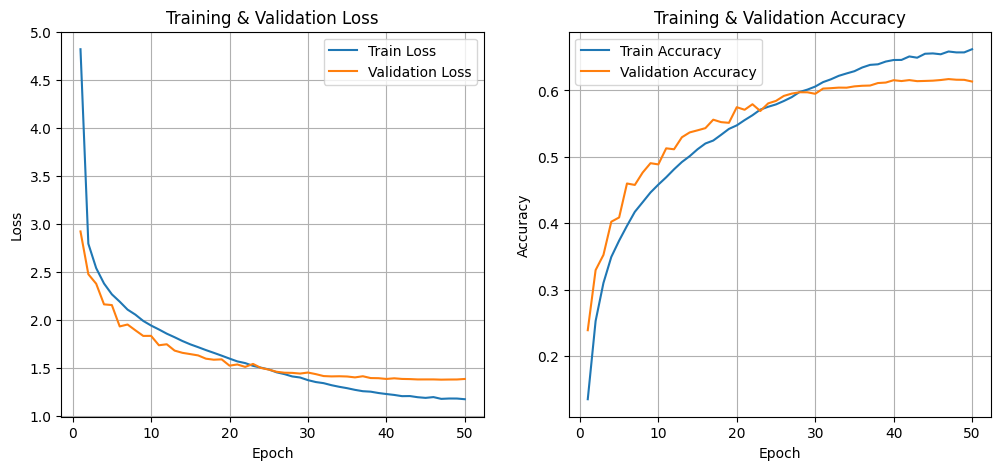

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.48      0.42      0.45       360
     antenna       0.63      0.54      0.58       360
    bacteria       0.69      0.65      0.67       360
     battery       0.55      0.60      0.58       360
        bean       0.55      0.55      0.55       360
      beetle       0.66      0.73      0.69       360
     bicycle       0.77      0.71      0.74       360
       birch       0.56      0.57      0.56       360
        bird       0.41      0.38      0.40       360
        bomb       0.70      0.57      0.63       360
       bread       0.45      0.53      0.49       222
      bridge       0.61      0.67      0.64       360
      camera       0.63      0.74      0.68       360
      carbon       0.63      0.45      0.52       101
         cat       0.53      0.62      0.57       360
        corn       0.58      0.51      0.54       360
        crab       0.41      0.42      0.41       360
 crocodilian       0.57    

## Modyfikacje modelu

### Zmniejszenie `kernel_size`

In [ ]:
class ImageClassifier2(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2d4 = nn.BatchNorm2d(256)
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.fc1 = nn.Linear(4096, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))
        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))
        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))
        x = self.pool1(self.relu(self.bn2d4(self.conv4(x))))

        x = torch.flatten(x, start_dim=1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
# Check dims before flatten
model = ImageClassifier2(n_classes=50, hidden_1=256, hidden_2=128)
with torch.no_grad():
    x = torch.zeros(1, 3, 64, 64)
    x = model.conv1(x)
    x = model.bn2d1(x)
    x = model.pool1(x)
    x = model.conv2(x)
    x = model.pool1(x)
    x = model.conv3(x)
    x = model.pool1(x)
    x = model.conv4(x)
    x = model.pool1(x)
    print(x.shape)

torch.Size([1, 256, 4, 4])


In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier2(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn

In [ ]:
num_epochs = 50

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=5e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [00:53<00:00,  7.71it/s]


(Epoch 1/[train]) Loss:	4.586   Accuracy: 0.139   lr: 0.0006


100%|██████████| 138/138 [00:09<00:00, 15.12it/s]


(Epoch 1/[val]) Loss:	2.916   Accuracy: 0.231   lr: 0.0006


100%|██████████| 413/413 [00:52<00:00,  7.80it/s]


...

(Epoch 49/[val]) Loss:	1.369   Accuracy: 0.617   lr: 1.232616311222906e-05


 19%|█▉        | 78/413 [00:11<00:43,  7.66it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e604b4c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2e604b4c20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-p

(Epoch 50/[train]) Loss:	1.271   Accuracy: 0.634   lr: 1.0582115113659891e-05


100%|██████████| 138/138 [00:08<00:00, 15.41it/s]

(Epoch 50/[val]) Loss:	1.370   Accuracy: 0.616   lr: 1.0582115113659891e-05


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier2.pth')

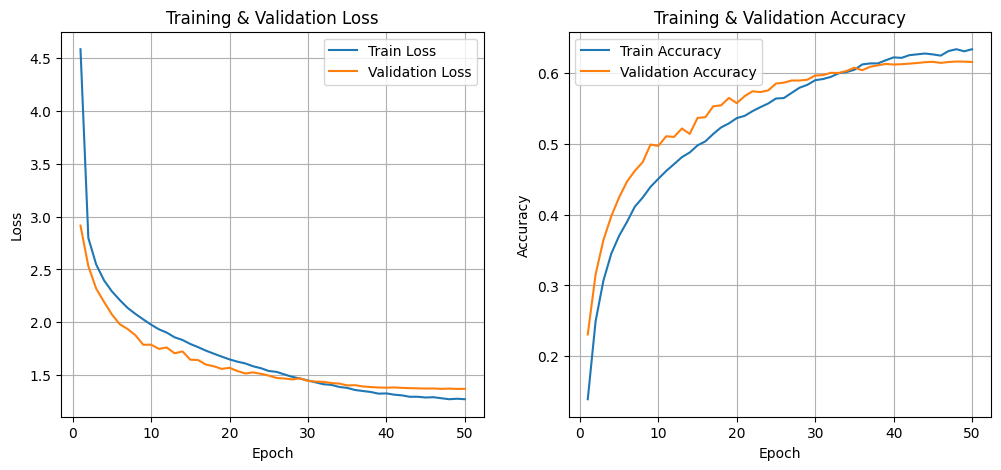

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.48      0.39      0.43       360
     antenna       0.63      0.55      0.59       360
    bacteria       0.68      0.65      0.66       360
     battery       0.53      0.58      0.56       360
        bean       0.60      0.54      0.57       360
      beetle       0.70      0.75      0.72       360
     bicycle       0.71      0.78      0.74       360
       birch       0.61      0.61      0.61       360
        bird       0.49      0.38      0.43       360
        bomb       0.64      0.56      0.59       360
       bread       0.55      0.54      0.54       222
      bridge       0.62      0.69      0.66       360
      camera       0.61      0.73      0.66       360
      carbon       0.49      0.44      0.46       101
         cat       0.54      0.62      0.58       360
        corn       0.60      0.52      0.56       360
        crab       0.45      0.47      0.46       360
 crocodilian       0.56    

### Większe wartości `out_channels` + AdaptiveAvgPool

In [ ]:
class ImageClassifier3(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn2d4 = nn.BatchNorm2d(512)
        self.avg_poll = nn.AdaptiveAvgPool2d((1,1))
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.fc1 = nn.Linear(512, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))
        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))
        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))
        x = self.pool1(self.relu(self.bn2d4(self.conv4(x))))

        x = torch.flatten(self.avg_poll(x), 1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
# Check dims before fc1
model = ImageClassifier3(n_classes=50, hidden_1=256, hidden_2=128)
with torch.no_grad():
    x = torch.zeros(1, 3, 64, 64)
    x = model.conv1(x)
    x = model.bn2d1(x)
    x = model.pool1(x)
    x = model.conv2(x)
    x = model.pool1(x)
    x = model.conv3(x)
    x = model.pool1(x)
    x = model.conv4(x)
    x = model.pool1(x)
    x = model.avg_poll(x)
    print(x.shape)

torch.Size([1, 512, 1, 1])


In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier3(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier3(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (avg_poll): AdaptiveAvgPool2d(output_size=(1, 1))
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Line

In [ ]:
num_epochs = 50

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=6e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [00:53<00:00,  7.73it/s]


(Epoch 1/[train]) Loss:	4.705   Accuracy: 0.115   lr: 0.0006


100%|██████████| 138/138 [00:09<00:00, 14.87it/s]


(Epoch 1/[val]) Loss:	3.112   Accuracy: 0.173   lr: 0.0006


100%|██████████| 413/413 [00:52<00:00,  7.83it/s]


...

(Epoch 49/[val]) Loss:	1.328   Accuracy: 0.628   lr: 1.232616311222906e-05


100%|██████████| 413/413 [00:53<00:00,  7.79it/s]


(Epoch 50/[train]) Loss:	1.280   Accuracy: 0.632   lr: 1.0582115113659891e-05


100%|██████████| 138/138 [00:08<00:00, 15.77it/s]

(Epoch 50/[val]) Loss:	1.325   Accuracy: 0.629   lr: 1.0582115113659891e-05


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier3.pth')

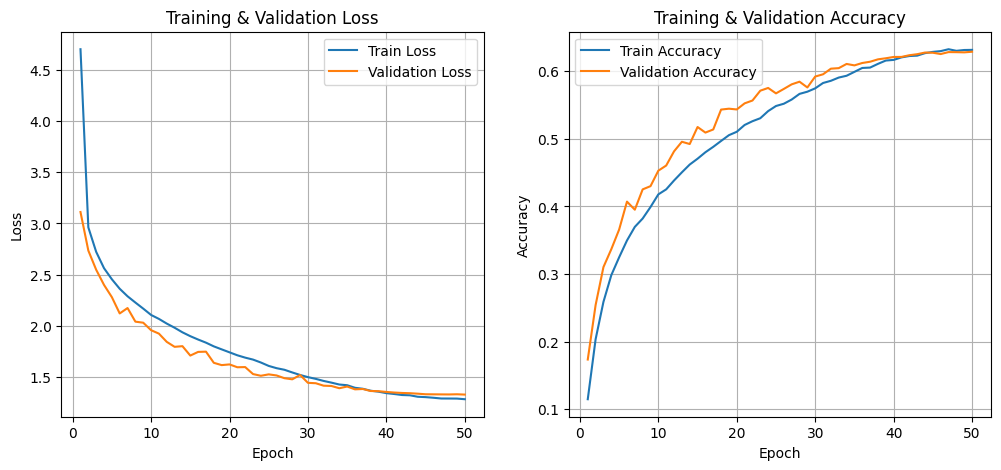

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.46      0.41      0.43       360
     antenna       0.60      0.50      0.54       360
    bacteria       0.71      0.70      0.71       360
     battery       0.55      0.57      0.56       360
        bean       0.61      0.57      0.59       360
      beetle       0.69      0.72      0.71       360
     bicycle       0.79      0.74      0.77       360
       birch       0.61      0.64      0.63       360
        bird       0.42      0.40      0.41       360
        bomb       0.62      0.57      0.60       360
       bread       0.54      0.50      0.52       222
      bridge       0.60      0.70      0.65       360
      camera       0.65      0.72      0.68       360
      carbon       0.61      0.50      0.55       101
         cat       0.55      0.64      0.59       360
        corn       0.61      0.53      0.57       360
        crab       0.46      0.44      0.45       360
 crocodilian       0.55    

### Dodatkowa warstwa konwolucyjna

In [ ]:
class ImageClassifier4(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv5 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn2d5 = nn.BatchNorm2d(32)
        self.conv1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn2d4 = nn.BatchNorm2d(512)
        self.avg_poll = nn.AdaptiveAvgPool2d((1,1))
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.fc1 = nn.Linear(512, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu(self.bn2d5(self.conv5(x))))
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))
        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))
        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))
        x = self.pool1(self.relu(self.bn2d4(self.conv4(x))))

        x = torch.flatten(self.avg_poll(x), 1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier4(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier4(
  (conv5): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (avg_poll): AdaptiveAvgPool2d(output_size=(1, 1

In [ ]:
num_epochs = 48

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=6e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [00:55<00:00,  7.39it/s]


(Epoch 1/[train]) Loss:	4.664   Accuracy: 0.117   lr: 0.0006


100%|██████████| 138/138 [00:09<00:00, 13.99it/s]


(Epoch 1/[val]) Loss:	3.024   Accuracy: 0.191   lr: 0.0006


100%|██████████| 413/413 [00:57<00:00,  7.17it/s]


...

(Epoch 49/[val]) Loss:	1.331   Accuracy: 0.636   lr: 1.232616311222906e-05


100%|██████████| 413/413 [00:52<00:00,  7.81it/s]


(Epoch 50/[train]) Loss:	1.094   Accuracy: 0.687   lr: 1.0582115113659891e-05


100%|██████████| 138/138 [00:09<00:00, 15.10it/s]

(Epoch 50/[val]) Loss:	1.332   Accuracy: 0.637   lr: 1.0582115113659891e-05


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier4.pth')

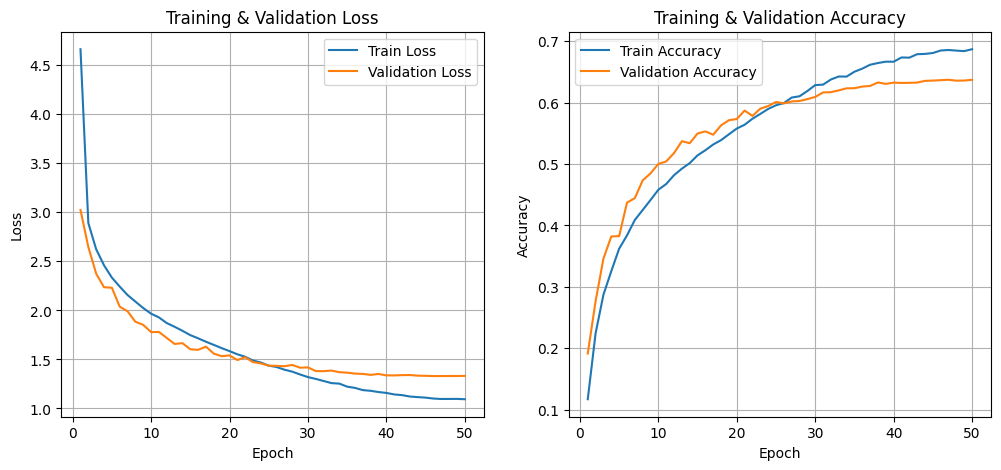

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.47      0.44      0.46       360
     antenna       0.62      0.56      0.59       360
    bacteria       0.71      0.70      0.71       360
     battery       0.57      0.61      0.59       360
        bean       0.61      0.61      0.61       360
      beetle       0.73      0.72      0.73       360
     bicycle       0.77      0.71      0.74       360
       birch       0.58      0.59      0.59       360
        bird       0.44      0.45      0.44       360
        bomb       0.66      0.58      0.62       360
       bread       0.57      0.51      0.54       222
      bridge       0.62      0.69      0.66       360
      camera       0.69      0.71      0.70       360
      carbon       0.57      0.47      0.51       101
         cat       0.53      0.64      0.58       360
        corn       0.60      0.51      0.55       360
        crab       0.46      0.46      0.46       360
 crocodilian       0.57    

### Połączenia rezydualne

In [ ]:
class ImageClassifier5(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv5 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn2d5 = nn.BatchNorm2d(32)

        self.conv1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)

        self.res1a = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2dr1a = nn.BatchNorm2d(64)
        self.res1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2dr1b = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(128)

        self.res2a = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn2dr2a = nn.BatchNorm2d(128)
        self.res2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn2dr2b = nn.BatchNorm2d(128)


        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(256)

        self.res3a = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn2dr3a = nn.BatchNorm2d(256)
        self.res3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn2dr3b = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn2d4 = nn.BatchNorm2d(512)

        self.avg_poll = nn.AdaptiveAvgPool2d((1,1))

        self.bn1 = nn.BatchNorm1d(hidden_1)

        self.fc1 = nn.Linear(512, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu(self.bn2d5(self.conv5(x))))
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))

        identity = x
        x = self.relu(self.bn2dr1a(self.res1a(x)))
        x = self.bn2dr1b(self.res1b(x))
        x = self.relu(x + identity)

        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))

        identity = x
        x = self.relu(self.bn2dr2a(self.res2a(x)))
        x = self.bn2dr2b(self.res2b(x))
        x = self.relu(x + identity)

        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))

        # identity = x
        # x = self.relu(self.bn2dr3a(self.res3a(x)))
        # x = self.bn2dr3b(self.res3b(x))
        # x = self.relu(x + identity)

        x = self.relu(self.bn2d4(self.conv4(x)))

        x = torch.flatten(self.avg_poll(x), 1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier5(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier5(
  (conv5): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res1a): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2dr1a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res1b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2dr1b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res2a): Conv2d(128, 128, kernel_size=(3, 3), str

In [ ]:
num_epochs = 60

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=8e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [00:55<00:00,  7.42it/s]


(Epoch 1/[train]) Loss:	4.361   Accuracy: 0.104   lr: 0.0008


100%|██████████| 138/138 [00:08<00:00, 16.87it/s]


(Epoch 1/[val]) Loss:	3.088   Accuracy: 0.170   lr: 0.0008


100%|██████████| 413/413 [00:53<00:00,  7.74it/s]


...

(Epoch 49/[val]) Loss:	1.285   Accuracy: 0.663   lr: 8.543828722189585e-05


100%|██████████| 413/413 [00:53<00:00,  7.75it/s]


(Epoch 50/[train]) Loss:	0.822   Accuracy: 0.756   lr: 7.372512566155758e-05


100%|██████████| 138/138 [00:08<00:00, 17.03it/s]

(Epoch 50/[val]) Loss:	1.293   Accuracy: 0.665   lr: 7.372512566155758e-05
Early stopping at epoch 50


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier5.pth')

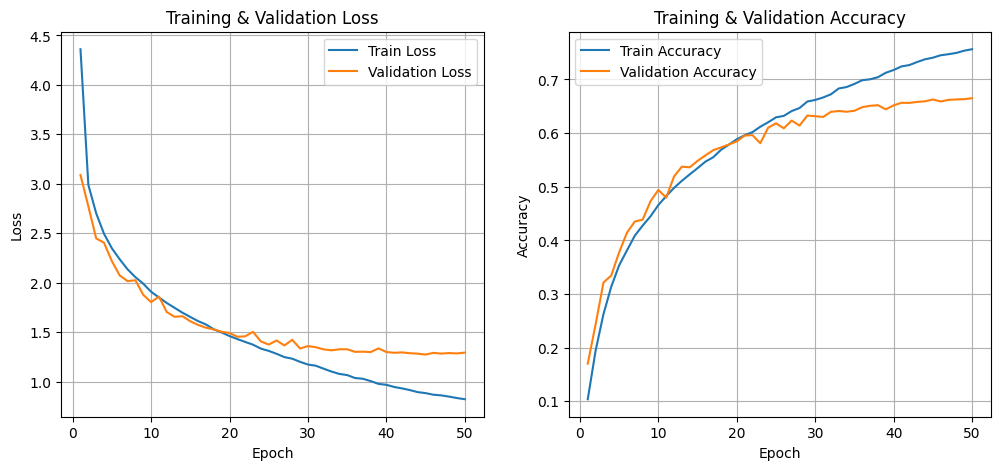

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.54      0.51      0.52       360
     antenna       0.60      0.60      0.60       360
    bacteria       0.76      0.67      0.71       360
     battery       0.60      0.65      0.62       360
        bean       0.58      0.68      0.63       360
      beetle       0.72      0.75      0.74       360
     bicycle       0.82      0.71      0.76       360
       birch       0.59      0.69      0.63       360
        bird       0.51      0.46      0.48       360
        bomb       0.64      0.60      0.62       360
       bread       0.61      0.55      0.58       222
      bridge       0.67      0.69      0.68       360
      camera       0.70      0.72      0.71       360
      carbon       0.60      0.50      0.54       101
         cat       0.59      0.66      0.62       360
        corn       0.63      0.56      0.60       360
        crab       0.55      0.48      0.51       360
 crocodilian       0.56    

### Dodatkowe połączenie rezydualne

In [ ]:
class ImageClassifier6(nn.Module):
    def __init__(self, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.conv5 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn2d5 = nn.BatchNorm2d(32)

        self.conv1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2d1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)

        self.res1a = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2dr1a = nn.BatchNorm2d(64)
        self.res1b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bn2dr1b = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2d2 = nn.BatchNorm2d(128)

        self.res2a = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn2dr2a = nn.BatchNorm2d(128)
        self.res2b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn2dr2b = nn.BatchNorm2d(128)


        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn2d3 = nn.BatchNorm2d(256)

        self.res3a = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn2dr3a = nn.BatchNorm2d(256)
        self.res3b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn2dr3b = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn2d4 = nn.BatchNorm2d(512)

        self.avg_poll = nn.AdaptiveAvgPool2d((1,1))

        self.bn1 = nn.BatchNorm1d(hidden_1)

        self.fc1 = nn.Linear(512, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.bn2d5(self.conv5(x)))
        x = self.pool1(self.relu(self.bn2d1(self.conv1(x))))

        identity = x
        x = self.relu(self.bn2dr1a(self.res1a(x)))
        x = self.bn2dr1b(self.res1b(x))
        x = self.relu(x + identity)

        x = self.pool1(self.relu(self.bn2d2(self.conv2(x))))

        identity = x
        x = self.relu(self.bn2dr2a(self.res2a(x)))
        x = self.bn2dr2b(self.res2b(x))
        x = self.relu(x + identity)

        x = self.pool1(self.relu(self.bn2d3(self.conv3(x))))

        identity = x
        x = self.relu(self.bn2dr3a(self.res3a(x)))
        x = self.bn2dr3b(self.res3b(x))
        x = self.relu(x + identity)

        x = self.relu(self.bn2d4(self.conv4(x)))

        x = torch.flatten(self.avg_poll(x), 1)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

In [ ]:
num_classes = len(targets)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

image_classifier = ImageClassifier6(n_classes=num_classes, hidden_1=256, hidden_2=128)
image_classifier.to(device)

ImageClassifier6(
  (conv5): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res1a): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2dr1a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res1b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2dr1b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2d2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res2a): Conv2d(128, 128, kernel_size=(3, 3), str

In [ ]:
num_epochs = 60

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(image_classifier.parameters(), lr=8e-4, weight_decay=3e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(image_classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 413/413 [00:58<00:00,  7.01it/s]


(Epoch 1/[train]) Loss:	4.042   Accuracy: 0.110   lr: 0.0008


100%|██████████| 138/138 [00:10<00:00, 13.66it/s]


(Epoch 1/[val]) Loss:	3.150   Accuracy: 0.161   lr: 0.0008


100%|██████████| 413/413 [00:58<00:00,  7.09it/s]


...

(Epoch 59/[val]) Loss:	1.113   Accuracy: 0.703   lr: 1.2163851329532008e-05


100%|██████████| 413/413 [01:00<00:00,  6.83it/s]


(Epoch 60/[train]) Loss:	0.694   Accuracy: 0.791   lr: 1.0541333771943336e-05


100%|██████████| 138/138 [00:10<00:00, 13.63it/s]

(Epoch 60/[val]) Loss:	1.114   Accuracy: 0.704   lr: 1.0541333771943336e-05
Early stopping at epoch 60


In [ ]:
torch.save(image_classifier.state_dict(), 'image_classifier6.pth')

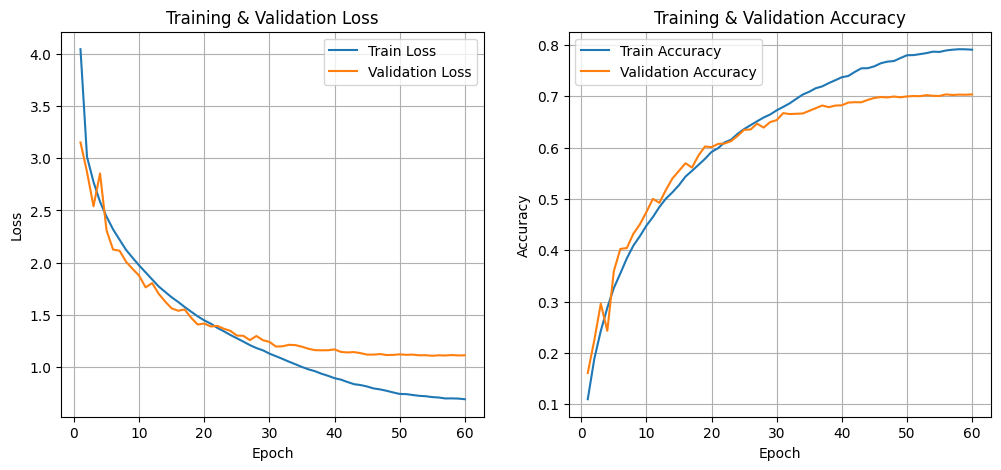

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = train_data.classes
preds, targets = get_predictions(image_classifier, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

    acoustic       0.57      0.51      0.54       360
     antenna       0.71      0.61      0.66       360
    bacteria       0.78      0.76      0.77       360
     battery       0.59      0.66      0.62       360
        bean       0.66      0.73      0.69       360
      beetle       0.77      0.78      0.77       360
     bicycle       0.79      0.84      0.81       360
       birch       0.64      0.68      0.66       360
        bird       0.56      0.51      0.53       360
        bomb       0.74      0.65      0.69       360
       bread       0.64      0.57      0.60       222
      bridge       0.72      0.73      0.73       360
      camera       0.78      0.75      0.76       360
      carbon       0.72      0.62      0.67       101
         cat       0.68      0.72      0.70       360
        corn       0.69      0.61      0.65       360
        crab       0.57      0.55      0.56       360
 crocodilian       0.64    

### Podsumowanie

Udało się się poprawić dokładność modelu z 57% do 69%.

Na polepszenie jakości modelu miały wpływ:

- **zwiększenie liczby augmentacji danych** - większa różnorodność obrazów treningowych

- **zwiększenie liczby kanałów wyjściowych w warstwach `conv`** - uzycie większej ilości filtrów konwolucyjnych

- **zwiększenie głębokości sieci** - dodanie dodatkowych warstw

- **dodanie połączeń rezydualnych** - dodanie wejścia warstwy do jej wyjścia


## Wygenerowanie predykcji

In [ ]:
eval_dataloader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
image_classifier.eval()
predictions = []

with torch.inference_mode():
    for X_batch, _ in eval_dataloader:
        X_batch = X_batch.to(device)

        logits = image_classifier(X_batch).squeeze()
        _, preds = torch.max(logits, dim=1)
        predictions.extend(preds.tolist())

In [ ]:
assert(len(predictions) == len(test_data))

In [ ]:
from pathlib import Path

filenames = [Path(p).name for p, _ in test_data.samples]

In [ ]:
results = pd.DataFrame({
    "image": filenames,
    "prediction": predictions
})

In [ ]:
results.head()

,image,prediction
0,IMG_000134.JPEG,13
1,IMG_000227.JPEG,23
2,IMG_000240.JPEG,49
3,IMG_000241.JPEG,34
4,IMG_000242.JPEG,15


In [ ]:
results.to_csv("pred.csv", index=False, header=False)